## **Predicting brain stroke risk using hybrid machine learning and deep learning models**

Dataset Link: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset

#### **Dataset Download**

**Google Colab**

In [1]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d jillanisofttech/brain-stroke-dataset

Dataset URL: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset
License(s): DbCL-1.0
100% 47.2k/47.2k [00:00<00:00, 62.4MB/s]



In [3]:
!unzip brain-stroke-dataset.zip
!1s *.csv

Archive:  brain-stroke-dataset.zip
  inflating: brain_stroke.csv        
/bin/bash: line 1: 1s: command not found


**VS Code (Recommended)**

In [4]:
import kaggle

dataset_link = "jillanisofttech/brain-stroke-dataset"

kaggle.api.authenticate()

kaggle.api.dataset_download_files(dataset_link, path=".", unzip=True)

print(f"{dataset_link} successfully downloaded")

Dataset URL: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset
jillanisofttech/brain-stroke-dataset successfully downloaded


In [5]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

#### **Loading Dataset**

In [6]:
stroke_df = pd.read_csv('brain_stroke.csv')
stroke_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


#### **Exploratory Data Analysis**

In [7]:
df = stroke_df.copy()

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


**Unique value count in each column**

In [8]:
for c in df.columns:
    print(f"{c} has {df[c].nunique()}")

gender has 2
age has 104
hypertension has 2
heart_disease has 2
ever_married has 2
work_type has 4
Residence_type has 2
avg_glucose_level has 3895
bmi has 342
smoking_status has 4
stroke has 2


In [9]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 4981 rows and 11 columns


**Gender column data mapping**

In [10]:
binary_cols = ['hypertension','heart_disease', 'stroke']

for col in binary_cols:
    df[col] = df[col].map({0:"No", 1:"Yes"})

In [11]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


**Gender distribution for TenYearCHD**

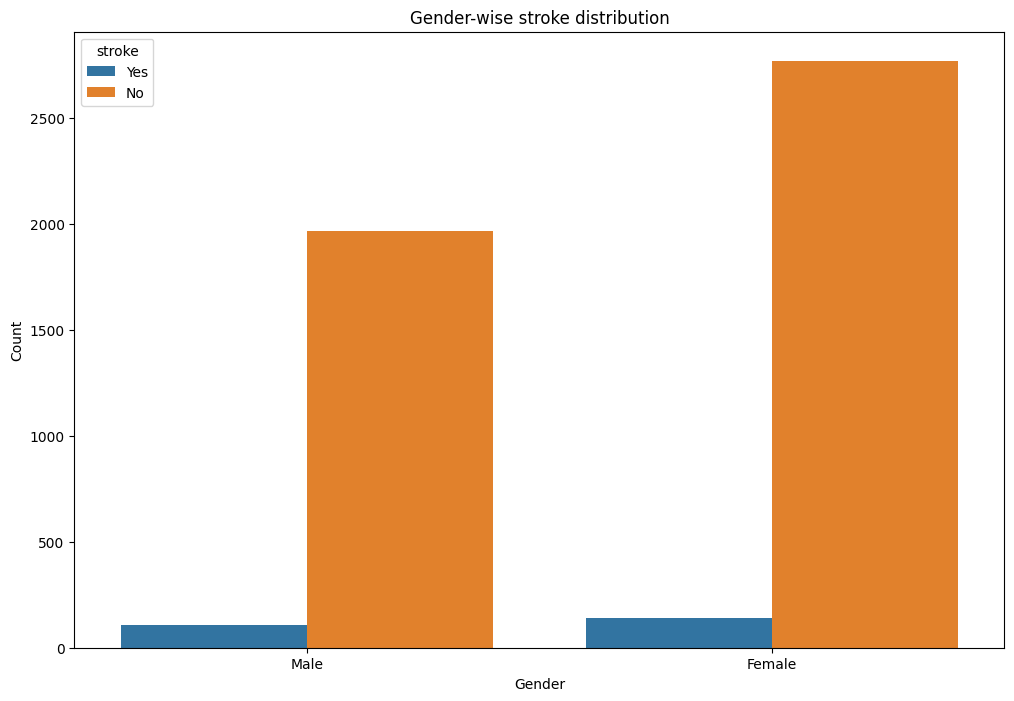

In [12]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='gender', hue='stroke')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender-wise stroke distribution")
plt.show()

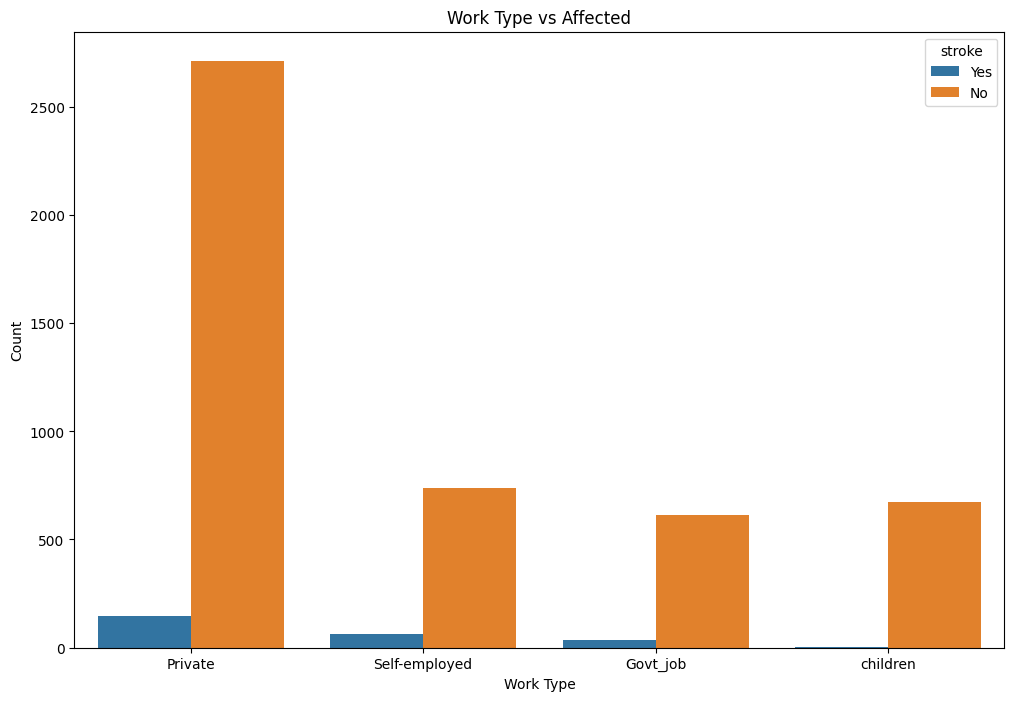

In [13]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='work_type', hue='stroke')
plt.xlabel("Work Type")
plt.ylabel("Count")
plt.title("Work Type vs Affected")
plt.show()

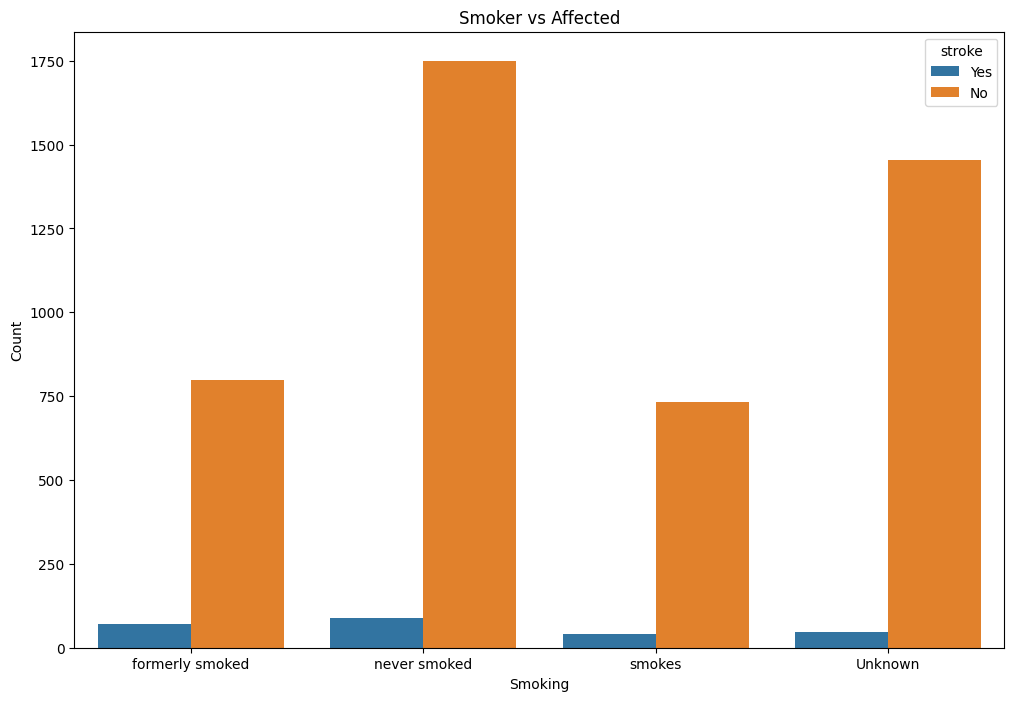

In [14]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='smoking_status', hue='stroke')
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.title("Smoker vs Affected")
plt.show()

**Has Blood Pressure**

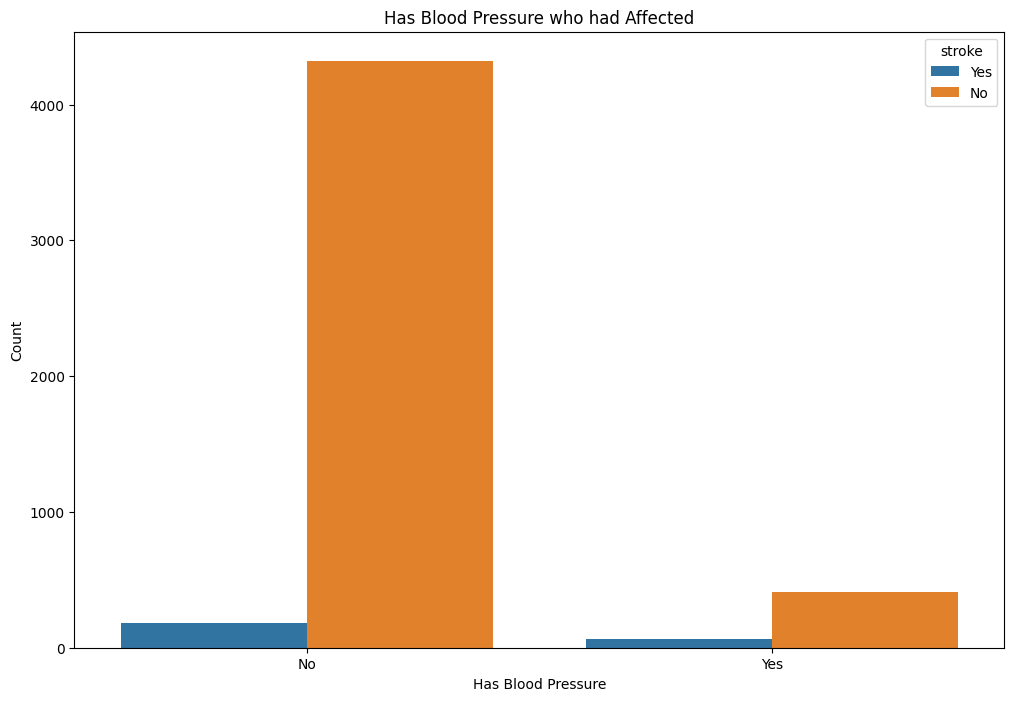

In [15]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='hypertension', hue='stroke')
plt.xlabel("Has Blood Pressure")
plt.ylabel("Count")
plt.title("Has Blood Pressure who had Affected")
plt.show()

**Has Stroke vs Affected**

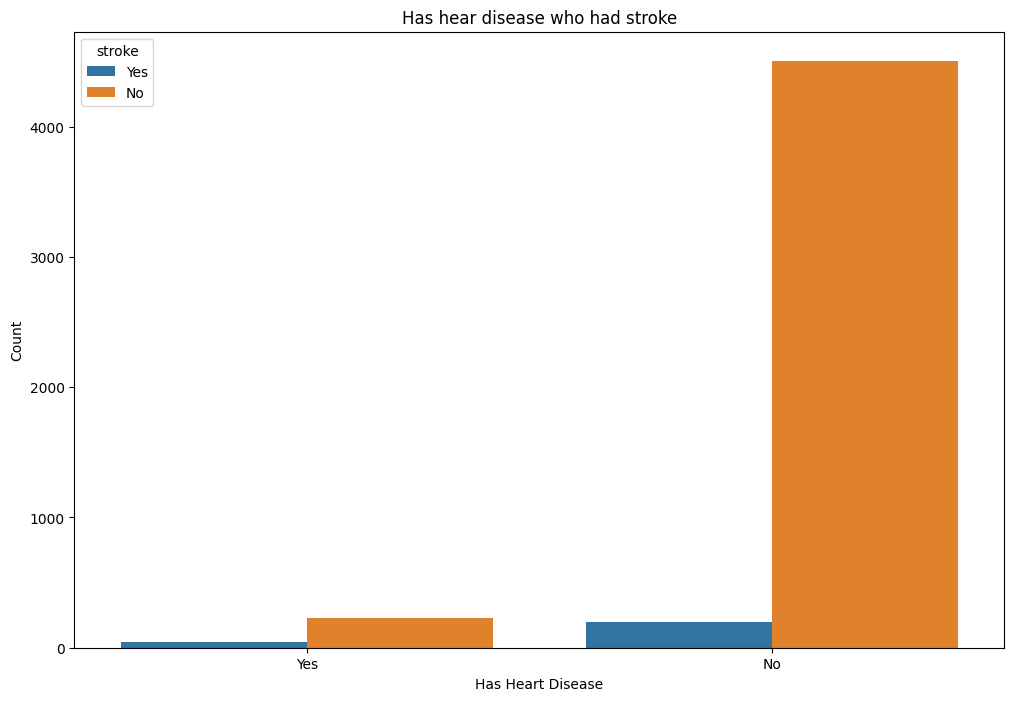

In [16]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='heart_disease', hue='stroke')
plt.xlabel("Has Heart Disease")
plt.ylabel("Count")
plt.title("Has hear disease who had stroke")
plt.show()

In [17]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


In [18]:
stroke_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


#### **Preprocessing**

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [20]:
stroke_data = stroke_df.copy()

**Basic Info**

In [21]:
print("Shape:", stroke_data.shape)
print("\nMissing values:\n", stroke_data.isnull().sum())
print("\nClass distribution:\n", stroke_data['stroke'].value_counts())

Shape: (4981, 11)

Missing values:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Class distribution:
 stroke
0    4733
1     248
Name: count, dtype: int64


**Feature Engineering**

In [22]:
cat_cols = ['gender', 'ever_married', 'work_type',
            'Residence_type', 'smoking_status']

data = pd.get_dummies(stroke_data, columns=cat_cols, drop_first=True)

In [23]:
# Age group
data['age_group'] = pd.cut(data['age'],
                           bins=[0, 30, 45, 60, 100],
                           labels=[0,1,2,3])

# Glucose risk
data['glucose_risk'] = np.where(data['avg_glucose_level'] > 140, 1, 0)

# BMI category
data['bmi_category'] = pd.cut(data['bmi'],
                              bins=[0,18.5,25,30,100],
                              labels=[0,1,2,3])

In [24]:
data['age_group'] = data['age_group'].astype(int)
data['bmi_category'] = data['bmi_category'].astype(int)

In [25]:
from sklearn.preprocessing import StandardScaler

X = data.drop('stroke', axis=1)
y = data['stroke']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Feature Selection**

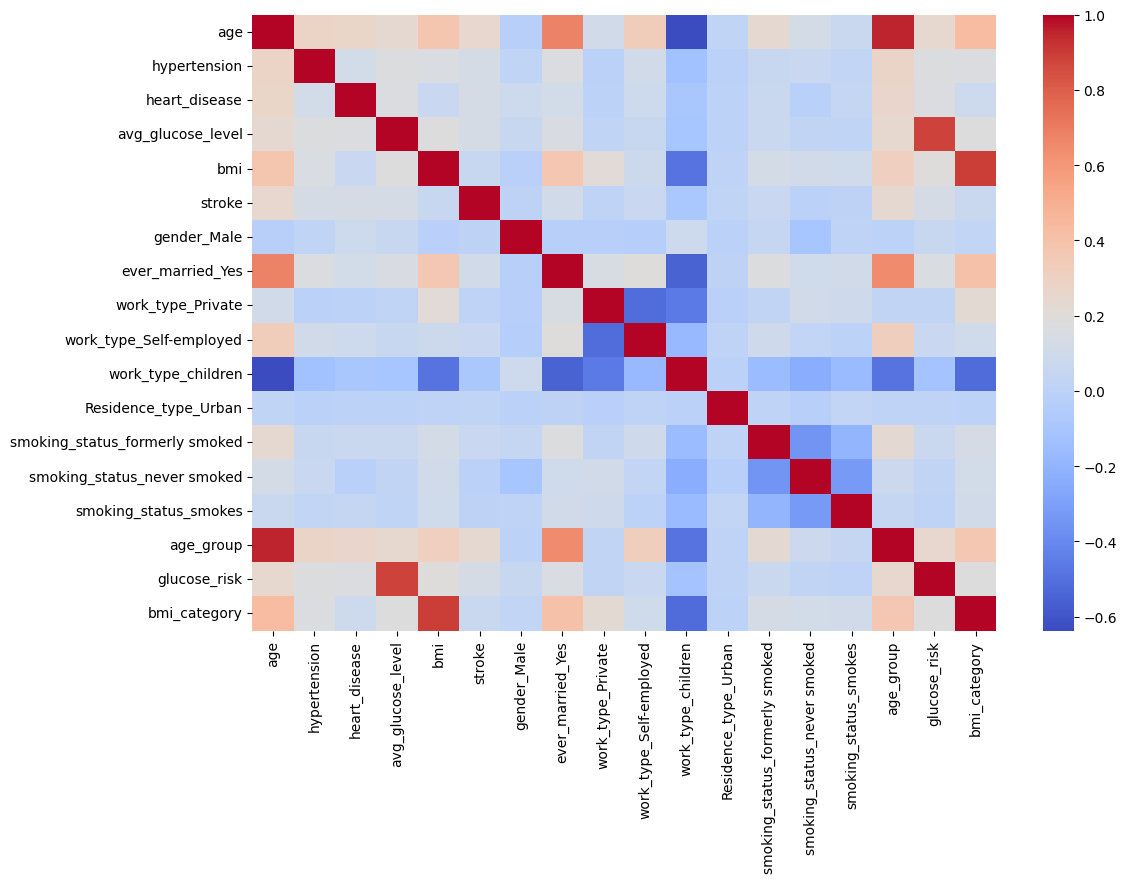

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

In [27]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=15)
X_new = selector.fit_transform(abs(X), y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

X = X[selected_features]

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'ever_married_Yes', 'work_type_Private', 'work_type_Self-employed',
       'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_smokes', 'age_group',
       'glucose_risk', 'bmi_category'],
      dtype='object')


#### **Train, Test Split**

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3984, 15)
Testing shape: (997, 15)
